# Regression Models: OLS, Lasso, and Ridge
Using CalEnviroScreen data to see if there is a relationship between hosting capacity and disadvantaged communities.

In [2]:
# import necessary libraries
import geopandas as gpd
import pandas as pd
import os
import matplotlib as plt
import numpy as np

# statistics
from sklearn.linear_model import LinearRegression
from sklearn.model_selection import train_test_split
from sklearn.linear_model import Lasso, Ridge
from sklearn.metrics import mean_squared_error, r2_score
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import RidgeCV
from sklearn.linear_model import LassoCV

In [3]:
os.environ['PROJ_LIB'] = '/opt/anaconda3/share/proj'

In [4]:
# read in data
cal = gpd.read_file("../../../../../../capstone/electrigrid/data/dis_adv_comm/calenviroscreen50_D_12226.gdb")
pge = gpd.read_parquet("../../../../../../capstone/electrigrid/data/census_hosting_capacity/pge_census_map_new.parquet")
sdge = gpd.read_parquet("../../../../../../capstone/electrigrid/data/census_hosting_capacity/sdge_census_map_new.parquet")
sce = gpd.read_parquet("../../../../../../capstone/electrigrid/data/census_hosting_capacity/sce_census_map_new.parquet")

## CalEnviroScreen data

In [19]:
cal.head(2)

,tract,ZIP,AppoxLoc,county,region,Population,CIscore,CIscore_Pctl,AirOzone,AirOzone_Pctl,...,PopOver_65,White_Pct,Hispanic_Pct,Black_Pct,NatAmeri_Pct,Asian_Pct,OtherMulti_Pct,Shape_Length,Shape_Area,geometry
0,6.001400e+09,94720,Berkeley,Alameda,Bay Area,3094.0,9.786846,10.388747,0.029251,6.028992,...,29.54,68.10,6.46,4.43,0.00,14.93,6.08,14229.013451,6.945853e+06,"MULTIPOLYGON (((-197333.073 -12225.564, -19731..."
1,6.001400e+09,94618,Oakland,Alameda,Bay Area,2093.0,7.181343,4.817809,0.028516,4.524489,...,25.51,67.27,9.36,2.05,0.67,12.23,8.41,3998.017070,5.865583e+05,"MULTIPOLYGON (((-198413.266 -16953.512, -19839..."


### Keep only certain variables of interest

In [6]:
cal_clean = cal[['tract', 'ZIP', 'Population', 'CIscore', 'AirOzone','AirPM25','Education', 'LinguisticIso', 'Poverty', 'Unemployment', 'White_Pct',
       'Hispanic_Pct', 'Black_Pct', 'NatAmeri_Pct', 'Asian_Pct','OtherMulti_Pct']]

## Utility data

In [21]:
# concatenate the three utilities into one
utility = pd.concat([pge, sdge, sce])

In [22]:
utility.head(2)

,GEOID,geometry,avg_DER_remain_pv_hh,avg_DER_remain_pv_opflex_hh,avg_DER_remain_generation_hh,avg_DER_remain_generation_opflex_hh,avg_DER_total_generation_hh,avg_DER_remain_load_hh,avg_DER_total_pv_hh,zillow_tract_hh_count
0,06085507002,"POLYGON ((-176262.283 -88639.818, -176244.255 ...",0.368304,0.129625,0.371032,0.101275,5.454829,1.503846,5.452101,534.0
1,06085504323,"POLYGON ((-167172.267 -66461.523, -167161.577 ...",3.042006,2.553713,2.494846,1.980096,8.368178,2.124298,8.915339,931.0


### Stats df

Join hosting capacity to census-tract-level sociodemographic variables.

In [7]:
# change tract column in `cal` to object
cal_clean['tract'] = cal_clean['tract'].astype('string')

# strip decimal (.0) at the end) -- ONLY RUN ONCE
cal_clean['tract'] = cal_clean['tract'].str[:-2] 

# add start 0 back in -- ONLY RUN ONCE
cal_clean['tract'] = '0' + cal_clean['tract']

/tmp/ipykernel_236239/2057411967.py:2: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  cal_clean['tract'] = cal_clean['tract'].astype('string')
/tmp/ipykernel_236239/2057411967.py:5: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  cal_clean['tract'] = cal_clean['tract'].str[:-2]
/tmp/ipykernel_236239/2057411967.py:8: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pa

In [14]:
stats = pd.merge(cal_clean, utility, left_on = "tract", right_on = "GEOID")

In [50]:
stats.head()

,tract,ZIP,AppoxLoc,county,region,Population,CIscore,CIscore_Pctl,AirOzone,AirOzone_Pctl,...,Shape_Length,Shape_Area,geometry_x,GEOID,zillow_tract_hh_count,avg_DER_remain_pv_hh,avg_DER_remain_load_hh,avg_DER_total_pv_hh,geometry_y,avg_DER_total_pv_opflex_hh
0,06001400100,94720,Berkeley,Alameda,Bay Area,3094.0,9.786846,10.388747,0.029251,6.028992,...,14229.013451,6.945853e+06,"MULTIPOLYGON (((-197333.073 -12225.564, -19731...",06001400100,412.0,0.070207,1.711574,NaN,"POLYGON ((-197333.073 -12225.563, -197310.342 ...",NaN
1,06001400200,94618,Oakland,Alameda,Bay Area,2093.0,7.181343,4.817809,0.028516,4.524489,...,3998.017070,5.865583e+05,"MULTIPOLYGON (((-198413.266 -16953.512, -19839...",06001400200,408.0,NaN,NaN,NaN,"POLYGON ((-198413.266 -16953.512, -198395.570 ...",NaN
2,06001400200,94618,Oakland,Alameda,Bay Area,2093.0,7.181343,4.817809,0.028516,4.524489,...,3998.017070,5.865583e+05,"MULTIPOLYGON (((-198413.266 -16953.512, -19839...",06001400200,185.0,1.245549,0.533618,1.503659,"POLYGON ((-198413.266 -16953.512, -198395.570 ...",NaN
3,06001400300,94618,Oakland,Alameda,Bay Area,5727.0,12.907937,18.972201,0.028516,4.524489,...,5317.707207,1.110836e+06,"MULTIPOLYGON (((-199103.674 -17489.695, -19909...",06001400300,1434.0,NaN,NaN,NaN,"POLYGON ((-199103.674 -17489.695, -199097.315 ...",NaN
4,06001400300,94618,Oakland,Alameda,Bay Area,5727.0,12.907937,18.972201,0.028516,4.524489,...,5317.707207,1.110836e+06,"MULTIPOLYGON (((-199103.674 -17489.695, -19909...",06001400300,994.0,1.571644,0.001033,1.727566,"POLYGON ((-199103.674 -17489.695, -199097.315 ...",NaN


## Basic linear regression

<Axes: ylabel='Frequency'>

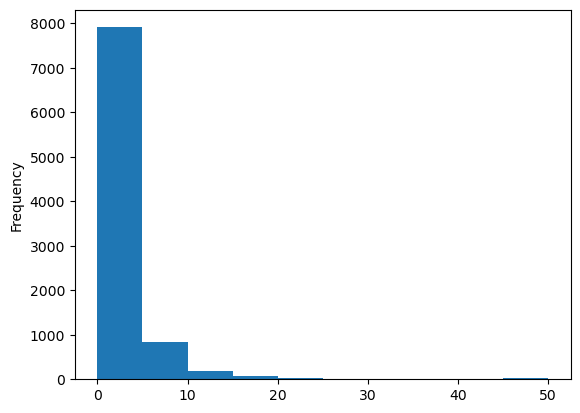

In [15]:
stats['avg_DER_remain_pv_hh'].plot(kind = "hist")

In [27]:
# drop NA values
stats = stats.dropna()

In [28]:
# initialize model
model_lm = LinearRegression()

# predictor variables (retrieved from cal.columns)
X = stats[['Population', 'CIscore', 'AirOzone','AirPM25','Education', 'LinguisticIso', 'Poverty', 'Unemployment', 'White_Pct',
       'Hispanic_Pct', 'Black_Pct', 'NatAmeri_Pct', 'Asian_Pct','OtherMulti_Pct']]

y = stats['avg_DER_remain_pv_hh']

# split data into training and test
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size = 0.3, random_state= 42) # need stratify?

# fit the scaler ONLY to X test (don't scale testing data)
scaler = StandardScaler().fit(X_train)

# create scaled versions of training data
X_train_s = scaler.transform(X_train)
X_test_s = scaler.transform(X_test)

In [29]:
# fit model
model_lm.fit(X_train_s, y_train)

# predict y
y_pred = model_lm.predict(X_test_s)

# Calculate MSE and R^2 for Ridge regression
lm_mse = mean_squared_error(y_test, y_pred)

In [30]:
lm_mse

15.546935908357446

A linear regression is perhaps not the best model. Figure out models that deal with a skewed regression.

### Lasso regression
To find which predictors are actually relevant

In [32]:
# initialize and fit model
lasso_model = Lasso()
lasso_model.fit(X_train_s, y_train)

lasso_predictions = lasso_model.predict(X_test_s)


# Calculate MSE and R^2 for Lasso regression
lasso_mse = mean_squared_error(y_test, lasso_predictions)
lasso_r2 = r2_score(y_test, lasso_predictions)



print("Lasso Regression MSE:", lasso_mse)
print("Lasso Regression R²:", lasso_r2)

Lasso Regression MSE: 16.346418940416275
Lasso Regression R²: -0.0010704603359084075


In [33]:
# Create and fit Ridge regression model
ridge_model = Ridge()
ridge_model.fit(X_train_s, y_train)

# Generate predictions
ridge_predictions = ridge_model.predict(X_test_s)

# Calculate MSE and R^2 for Ridge regression
ridge_mse = mean_squared_error(y_test, ridge_predictions)
ridge_r2 = r2_score(y_test, ridge_predictions)

print("Ridge Regression MSE:", ridge_mse)
print("Ridge Regression R²:", ridge_r2)

Ridge Regression MSE: 15.546947261549969
Ridge Regression R²: 0.04788995628533799


In [36]:
# create table of feature names and their coefficients
table = {
    # feature names
    'Feature': ['Population', 'CIscore', 'AirOzone','AirPM25','Education', 'LinguisticIso', 'Poverty', 'Unemployment', 'White_Pct',
       'Hispanic_Pct', 'Black_Pct', 'NatAmeri_Pct', 'Asian_Pct','OtherMulti_Pct'],
    
    # OLS coefficients
    'Lasso Coefficient': lasso_model.coef_,
}

# convert to dataframe and print, so it appears in a table format
table = pd.DataFrame(table)
print(table.to_string(index=False))

       Feature  Lasso Coefficient
    Population                0.0
       CIscore                0.0
      AirOzone                0.0
       AirPM25                0.0
     Education                0.0
 LinguisticIso                0.0
       Poverty                0.0
  Unemployment                0.0
     White_Pct                0.0
  Hispanic_Pct                0.0
     Black_Pct                0.0
  NatAmeri_Pct                0.0
     Asian_Pct                0.0
OtherMulti_Pct                0.0


In [35]:
# remove all variables where Lasso brought them down to 0
table[table['Lasso Coefficient'] > 0]

,Feature,Lasso Coefficient


In [41]:
# create table of feature names and their coefficients
table = {
    # feature names
    'Feature': ['Population', 'CIscore', 'AirOzone','AirPM25','Education', 'LinguisticIso', 'Poverty', 'Unemployment', 'White_Pct',
       'Hispanic_Pct', 'Black_Pct', 'NatAmeri_Pct', 'Asian_Pct','OtherMulti_Pct'],
    
    # OLS coefficients
    'Ridge Coefficient': ridge_model.coef_,
}

# convert to dataframe and print, so it appears in a table format
table = pd.DataFrame(table)
print(table.to_string(index=False))

       Feature  Ridge Coefficient
    Population           0.050281
       CIscore           0.233581
      AirOzone          -0.203904
       AirPM25           0.812255
     Education          -0.516380
 LinguisticIso          -0.172657
       Poverty           0.120933
  Unemployment          -0.181378
     White_Pct          -0.044139
  Hispanic_Pct          -0.136650
     Black_Pct          -0.150106
  NatAmeri_Pct           0.068051
     Asian_Pct           0.313653
OtherMulti_Pct          -0.012179


### Lasso and Ridge with Cross Validation

In [43]:
lambdas = np.logspace(-4,4, 100)

# initialize model
lasso_cv = LassoCV(alphas=lambdas, cv=10)

# fit to training data
lasso_cv.fit(X_train_s, y_train)

# explore best lambda
print(f'The best lambda value for this model is {lasso_cv.alpha_}.')

The best lambda value for this model is 0.018307382802953697.


In [44]:
lasso_cv.coef_

array([ 0.02568126,  0.13638041, -0.16043309,  0.78688431, -0.45877511,
       -0.10893532,  0.03708301, -0.14289907,  0.        , -0.04818293,
       -0.08564023,  0.05520763,  0.32133278,  0.        ])

In [45]:
# create table of feature names and their coefficients
table = {
    # feature names
    'Feature': ['Population', 'CIscore', 'AirOzone','AirPM25','Education', 'LinguisticIso', 'Poverty', 'Unemployment', 'White_Pct',
       'Hispanic_Pct', 'Black_Pct', 'NatAmeri_Pct', 'Asian_Pct','OtherMulti_Pct'],
    
    # OLS coefficients
    'Lasso Coefficient': lasso_cv.coef_,
}

# convert to dataframe and print, so it appears in a table format
table = pd.DataFrame(table)
#print(table.to_string(index=False))

In [46]:
table[table['Lasso Coefficient'] > 0 ]

,Feature,Lasso Coefficient
0,Population,0.025681
1,CIscore,0.136380
3,AirPM25,0.786884
6,Poverty,0.037083
11,NatAmeri_Pct,0.055208
12,Asian_Pct,0.321333


In [48]:
# initialize and fit model
lasso_model = Lasso()
lasso_model.fit(X_train_s, y_train)

lasso_cv_pred = lasso_cv.predict(X_test_s)


# Calculate MSE and R^2 for Lasso regression
lasso_cv_mse = mean_squared_error(y_test, lasso_cv_pred)
lasso_cv_r2 = r2_score(y_test, lasso_predictions)

In [49]:
lasso_cv_mse

15.531465114826055

In [50]:
# initiate model
ridge_cv = RidgeCV(alphas=lambdas, cv=10, scoring='neg_mean_squared_error')

# fit to training data
ridge_cv.fit(X_train_s, y_train)

# explore best lambda
print(f'The best lambda value for this model is {ridge_cv.alpha_}.')

The best lambda value for this model is 291.5053062825182.


In [51]:
# predict using the test set
y_test_pred_rcv = ridge_cv.predict(X_test_s)

# compute MSE
mse_rcv = mean_squared_error(y_test, y_test_pred_rcv)

In [52]:
mse_rcv

15.541874676152025

In [67]:
y_test_pred_rcv = y_test_pred_rcv.values.reshape(1, -1)

AttributeError: 'numpy.ndarray' object has no attribute 'values'

In [66]:
ridge_cv.score(y_test, y_test_pred_rcv)

ValueError: X has 2694 features, but RidgeCV is expecting 14 features as input.

In [54]:
# create table of feature names and their coefficients
table = {
    # feature names
    'Feature': ['Population', 'CIscore', 'AirOzone','AirPM25','Education', 'LinguisticIso', 'Poverty', 'Unemployment', 'White_Pct',
       'Hispanic_Pct', 'Black_Pct', 'NatAmeri_Pct', 'Asian_Pct','OtherMulti_Pct'],
    
    # OLS coefficients
    'Ridge Coefficient': ridge_cv.coef_,
}

# convert to dataframe and print, so it appears in a table format
table = pd.DataFrame(table)
print(table.to_string(index=False))

       Feature  Ridge Coefficient
    Population           0.047935
       CIscore           0.204112
      AirOzone          -0.171407
       AirPM25           0.765822
     Education          -0.432915
 LinguisticIso          -0.155194
       Poverty           0.070755
  Unemployment          -0.169900
     White_Pct          -0.036383
  Hispanic_Pct          -0.144690
     Black_Pct          -0.128446
  NatAmeri_Pct           0.063702
     Asian_Pct           0.302938
OtherMulti_Pct          -0.003602


In [129]:
table

,Feature,Lasso Coefficient
0,Population,-0.154382
1,CIscore,0.017967
2,CIscore_Pctl,0.013803
3,AirOzone,0.121372
4,AirOzone_Pctl,0.130628
...,...,...
59,Hispanic_Pct,-0.068364
60,Black_Pct,0.016726
61,NatAmeri_Pct,0.026541
62,Asian_Pct,0.095006


### Using fewer variables

In [55]:
race = stats[['Poverty',
       'Unemployment', 'White_Pct',
       'Hispanic_Pct', 'Black_Pct', 'NatAmeri_Pct', 'Asian_Pct',
       'OtherMulti_Pct', 'avg_DER_remain_pv_hh']]

In [56]:
race

,Poverty,Unemployment,White_Pct,Hispanic_Pct,Black_Pct,NatAmeri_Pct,Asian_Pct,OtherMulti_Pct,avg_DER_remain_pv_hh
0,8.780488,5.454545,68.10,6.46,4.43,0.00,14.93,6.08,0.152437
1,9.603440,5.249110,67.27,9.36,2.05,0.67,12.23,8.41,0.412830
2,9.603440,5.249110,67.27,9.36,2.05,0.67,12.23,8.41,0.973503
3,11.004030,7.127253,58.76,8.68,9.15,0.37,10.63,12.41,0.714527
4,11.004030,7.127253,58.76,8.68,9.15,0.37,10.63,12.41,1.235486
...,...,...,...,...,...,...,...,...,...
9086,20.178306,4.305284,76.08,8.77,0.92,0.00,2.05,12.18,0.940089
9087,51.808905,7.340946,81.12,10.99,1.81,0.56,0.05,5.47,0.112277
9088,51.808905,7.340946,81.12,10.99,1.81,0.56,0.05,5.47,3.156833
9089,30.947581,0.881057,87.10,2.22,0.00,1.31,9.07,0.30,0.000000


In [57]:
race = race.dropna()

In [58]:
X = race[['Poverty',
       'Unemployment', 'White_Pct',
       'Hispanic_Pct', 'Black_Pct', 'NatAmeri_Pct', 'Asian_Pct',
       'OtherMulti_Pct']]
y = race['avg_DER_remain_pv_hh']

# split data into training and test
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size = 0.3, random_state= 42) # need stratify?

# fit the scaler ONLY to X test (don't scale testing data)
scaler = StandardScaler().fit(X_train)

# create scaled versions of training data
X_train_s = scaler.transform(X_train)
X_test_s = scaler.transform(X_test)

In [59]:
race_model = LinearRegression().fit(X_train_s, y_train)

In [60]:
y_pred = race_model.predict(X_test_s)

In [61]:
mse = mean_squared_error(y_test, y_pred)

In [62]:
mse

16.035574631468084